In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_sellers_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_geolocation_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/product_category_name_translation.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv
/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv


In [2]:
customer_df = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_customers_dataset.csv')
geoloc_df = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_geolocation_dataset.csv')
order_items_df = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_items_dataset.csv')
payments_df = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_payments_dataset.csv')
order_review_df = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_order_reviews_dataset.csv')
orders_df = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_orders_dataset.csv')
product_df = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_products_dataset.csv')
sellers_df = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/olist_sellers_dataset.csv')
category_name_df = pd.read_csv('/kaggle/input/datasets/organizations/olistbr/brazilian-ecommerce/product_category_name_translation.csv')

In [3]:
'''Исходный payments_df может содержать несколько записей на один заказ например, если заказ 
оплачивался частями или разными способами, как и review_df могут быть оставленны несколько раз на один товар.
Поэтому мы их групперуем'''

payments_agg = (payments_df
               .groupby('order_id')
               .agg(
                   total_payment=('payment_value', 'sum'),
                   payment_installments = ('payment_installments', 'max'),
                   payment_type = ('payment_type', 'first')
               ).reset_index()
        )

reviews_agg = (order_review_df
             .groupby('order_id')
             .agg(
                 review_score = ('review_score', 'first'),
                 review_comment = ('review_comment_message', 'first')
             ).reset_index()
        )

master_df = (orders_df
    .merge(customer_df, on='customer_id', how='left')
    .merge(order_items_df, on='order_id', how='left')
    .merge(product_df, on='product_id', how='left')
    .merge(category_name_df, on='product_category_name', how='left')
    .merge(sellers_df, on='seller_id', how='left')
    .merge(payments_agg, on='order_id', how='left')
    .merge(reviews_agg, on='order_id', how='left')
)

# Проверка
print("Строк:", len(master_df))
print("Дублей:", master_df.duplicated(subset=['order_id', 'product_id']).sum())
print("Выручка master:", master_df['price'].sum().round(2))
print("Выручка items: ", order_items_df['price'].sum().round(2))

Строк: 113425
Дублей: 10225
Выручка master: 13591643.7
Выручка items:  13591643.7


In [4]:
missing_data = master_df.isnull().sum()
missing_persent = (missing_data/ len(master_df)) * 100

missing_df = pd.DataFrame({
    'Пропуски' : missing_data,
    'Процент' : missing_persent
}).sort_values(by='Пропуски', ascending=False)

missing_df = missing_df[missing_df['Пропуски'] > 0]


print("АНАЛИЗ ПРОПУСКОВ В ДАННЫХ")

print(missing_df.round(2))
print(f"\nВсего колонок с пропусками: {len(missing_df)}")
print(f"Общее количество строк в мастер-таблице: {len(master_df):,}")

АНАЛИЗ ПРОПУСКОВ В ДАННЫХ
                               Пропуски  Процент
review_comment                    65430    57.69
order_delivered_customer_date      3229     2.85
product_category_name_english      2402     2.12
product_name_lenght                2378     2.10
product_photos_qty                 2378     2.10
product_description_lenght         2378     2.10
product_category_name              2378     2.10
order_delivered_carrier_date       1968     1.74
review_score                        961     0.85
product_length_cm                   793     0.70
product_weight_g                    793     0.70
product_height_cm                   793     0.70
product_width_cm                    793     0.70
seller_zip_code_prefix              775     0.68
order_item_id                       775     0.68
price                               775     0.68
seller_id                           775     0.68
product_id                          775     0.68
shipping_limit_date                 775    

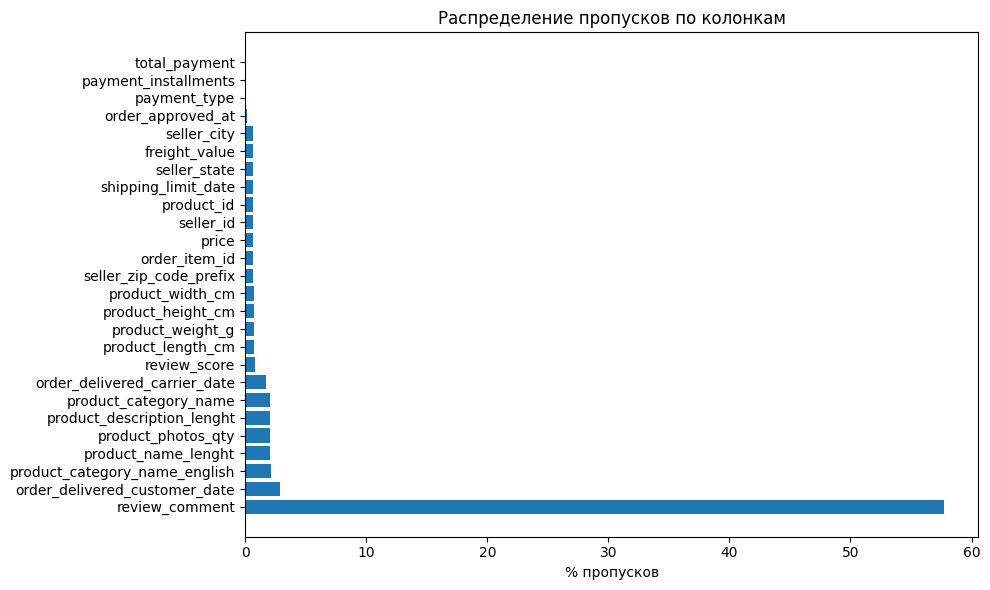

In [5]:
plt.figure(figsize=(10, 6))
missing_sorted = missing_df.sort_values(by='Пропуски', ascending=False)
plt.barh(missing_sorted.index, missing_sorted["Процент"])
plt.xlabel("% пропусков")
plt.title('Распределение пропусков по колонкам')
plt.tight_layout()
plt.show()

In [6]:
#Чистка и заполнение пропусков
master_df = master_df[master_df['seller_id'].notna()]
master_df = master_df[master_df['product_category_name'].notna()]
master_df = master_df[master_df['product_id'].notna()]
master_df['product_category_name_english'] = master_df['product_category_name_english'].fillna('unknown')

for col in ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']:
    if col in master_df.columns:
        median_val = master_df[col].median()
        master_df[col] = master_df[col].fillna(median_val)

In [7]:
import pandas as pd
import sqlite3
import numpy as np

# SQL иммитация
# 1. СОЗДАЁМ БАЗУ ДАННЫХ SQLITE


# Подключаемся к базе 
conn = sqlite3.connect(':memory:')

# Сохраняем данные в память
master_df.to_sql('master_table', conn, if_exists='replace', index=False)

print("База данных создана ")
print(f"Таблица 'master_table' содержит {len(master_df):,} строк")

База данных создана 
Таблица 'master_table' содержит 111,047 строк


In [8]:
query = """
    SELECT 
 
        COUNT(DISTINCT order_id) AS total_orders,
        COUNT(DISTINCT customer_unique_id) AS total_customers,
        COUNT(DISTINCT seller_id) AS total_sellers,
        COUNT(DISTINCT product_id) AS total_products,
        COUNT(DISTINCT product_category_name_english) AS total_categories,
    
        ROUND(SUM(total_payment), 2) AS total_revenue,
        ROUND(AVG(order_total), 2) AS avg_order_value,
        ROUND(SUM(CASE WHEN order_status = 'delivered' THEN 1 ELSE 0 END) * 100.0 / COUNT(DISTINCT order_id), 1) AS delivery_rate,
    
        COUNT(DISTINCT customer_state) AS total_states,
        COUNT(DISTINCT customer_city) AS total_cities
    FROM (
        SELECT
            order_id,
            customer_unique_id,
            seller_id,
            product_id,
            product_category_name_english,
            total_payment,
            order_status,
            customer_state,
            customer_city,
            SUM(total_payment) OVER (PARTITION BY order_id) AS order_total
        FROM master_table
    )
""" 
metrics_df = pd.read_sql_query(query, conn)

print("ОСНОВНЫЕ МЕТРИКИ БИЗНЕСА")
print(metrics_df.to_string(index=False))

ОСНОВНЫЕ МЕТРИКИ БИЗНЕСА
 total_orders  total_customers  total_sellers  total_products  total_categories  total_revenue  avg_order_value  delivery_rate  total_states  total_cities
        97277            94108           3035           32341                72     20055333.0           354.53          111.7            27          4095


ДИНАМИКА ЗАКАЗОВ ПО МЕСЯЦАМ
  month  orders    revenue  avg_order_value  unique_customers
2016-09       3     347.52           206.66                 3
2016-10     306   73818.66           387.85               303
2016-12       1      19.62            19.62                 1
2017-01     778  185733.92           514.22               745
2017-02    1681  333177.09           267.45              1659
2017-03    2589  517484.65           276.80              2552
2017-04    2329  493728.16           310.77              2298
2017-05    3577  710249.17           286.87              3507
2017-06    3163  592189.12           260.03              3100
2017-07    3918  732200.38           286.14              3846
2017-08    4227  862173.48           457.93              4148
2017-09    4183 1005176.95           535.59              4112
2017-10    4513  991931.50           393.53              4446
2017-11    7345 1565721.40           400.60              7239
2017-12    5489 1022777.73           276.3

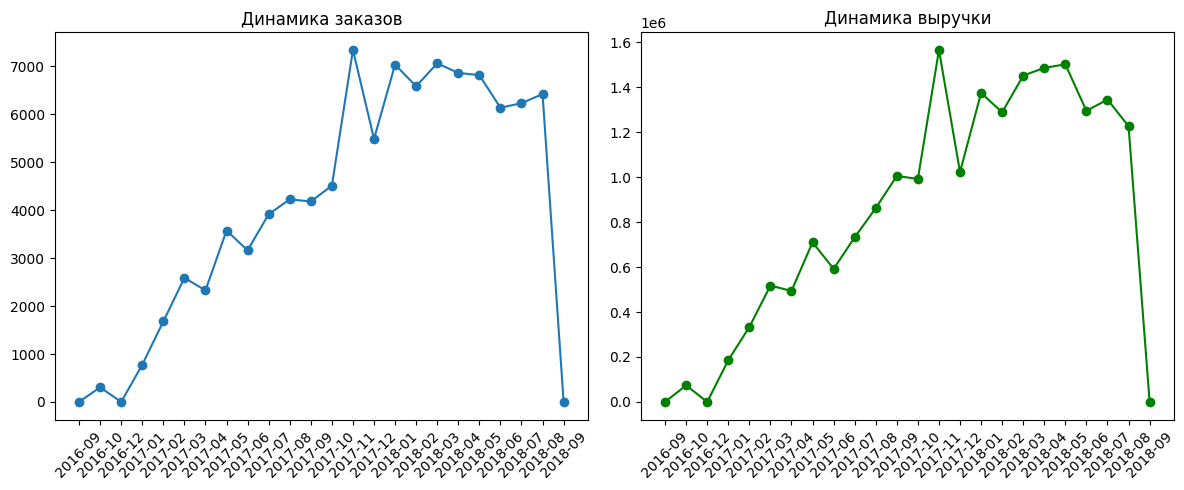

In [9]:
query = """
    SELECT 
        strftime('%Y-%m', order_purchase_timestamp) AS month,
        COUNT(DISTINCT order_id) as orders,
        ROUND(SUM(total_payment), 2) AS revenue,
        ROUND(AVG(order_total), 2) AS avg_order_value,
        COUNT(DISTINCT customer_unique_id) AS unique_customers
    FROM (
        SELECT
            order_id,
            order_purchase_timestamp,
            customer_unique_id,
            total_payment,
            SUM(total_payment) OVER (PARTITION BY order_id) AS order_total
        FROM master_table
    )

    GROUP BY strftime('%Y-%m', order_purchase_timestamp)
    ORDER BY month
        
"""

month_df = pd.read_sql_query(query, conn)

print("ДИНАМИКА ЗАКАЗОВ ПО МЕСЯЦАМ")
print(month_df.to_string(index=False))


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(month_df['month'], month_df['orders'], marker='o')
plt.title('Динамика заказов')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.plot(month_df['month'], month_df['revenue'], marker='o', color='green')
plt.title('Динамика выручки')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
query = """
    SELECT 
        CAST(strftime('%w', order_purchase_timestamp) AS INTEGER) AS day_of_week,
        CASE CAST(strftime('%w', order_purchase_timestamp) AS INTEGER)
            WHEN 0 THEN 'Воскресенье'
            WHEN 1 THEN 'Понедельник'
            WHEN 2 THEN 'Вторник'
            WHEN 3 THEN 'Среда'
            WHEN 4 THEN 'Четверг'
            WHEN 5 THEN 'Пятница'
            WHEN 6 THEN 'Суббота'
        END AS day_name,
        
        COUNT(DISTINCT order_id) AS orders,
        ROUND(SUM(total_payment), 2) AS revenue
    FROM master_table
    GROUP BY CAST(strftime('%w', order_purchase_timestamp) AS INTEGER)
    ORDER BY day_of_week
        
"""

weekly_df = pd.read_sql_query(query, conn)

print("ЗАКАЗЫ ПО ДНЯМ НЕДЕЛИ")
print(weekly_df.to_string(index=False))

ЗАКАЗЫ ПО ДНЯМ НЕДЕЛИ
 day_of_week    day_name  orders    revenue
           0 Воскресенье   11712 2245308.79
           1 Понедельник   15853 3268480.06
           2     Вторник   15608 3263844.21
           3       Среда   15194 3119518.06
           4     Четверг   14439 3053585.12
           5     Пятница   13819 2986523.45
           6     Суббота   10652 2118073.31


### **Ключевые тренды:**

#### * Ярко выраженный сезонный пик: ноябрь 2017 (+7 345 заказов, +1.56M выручки) — вероятно, связан с Чёрной пятницей.
#### * Рост бизнеса: с января 2017 (~778 заказов) до августа 2018 (~6 424 заказов) — рост в 8 раз.
#### * Провал в сентябре 2016 и ноябре 2016 (1–3 заказа) — вероятно, технические проблемы или старт проекта.
#### * В декабре 2017 — спад после пика ноября (5 489 заказов vs 7 345), что нормально для пост-сезонного периода.


### **Инсайты:**
#### 1. Среднемесячный темп роста — ~15–20% в активную фазу (2017–2018).
#### 2. Средний чек имеет сезонные колебания: высокие значения в сентябре 2017 (535 ₽) и августе 2018 (457 ₽).
#### 3. Уникальные клиенты стабильно растут, что говорит о расширении аудитории, а не только о накрутке повторных покупок.

### **Рекомендации:**

#### * Подготовить акции на ноябрь за 1–2 месяца, чтобы максимизировать результат в пиковый сезон.
#### * Увеличить маркетинговый бюджет в августе–сентябре для разогрева перед Чёрной пятницей.
#### * Анализировать причину низких показателей сентября 2016 и ноября 2016, чтобы избежать повторения.


In [11]:
query = """
    SELECT 
        CAST(strftime('%H', order_purchase_timestamp) AS INTEGER) AS hour,
        COUNT(DISTINCT order_id) AS orders,
        ROUND(SUM(total_payment), 2) AS revenue
    FROM master_table
    GROUP BY CAST(strftime('%H', order_purchase_timestamp) AS INTEGER)
    ORDER BY hour
"""
hourly_df = pd.read_sql_query(query, conn)

print("ЗАКАЗЫ ПО ЧАСАМ")
print(hourly_df.to_string(index=False))

ЗАКАЗЫ ПО ЧАСАМ
 hour  orders    revenue
    0    2345  461306.95
    1    1143  205397.72
    2     495   91194.20
    3     266   50217.02
    4     203   35431.98
    5     182   29038.04
    6     492   80454.96
    7    1205  221010.77
    8    2912  585712.89
    9    4664 1071281.19
   10    6025 1250704.20
   11    6432 1280130.01
   12    5854 1235956.87
   13    6374 1299851.83
   14    6422 1455432.10
   15    6316 1485432.10
   16    6528 1397144.73
   17    6013 1234061.72
   18    5647 1193937.25
   19    5848 1159438.63
   20    6076 1209363.26
   21    6081 1174142.54
   22    5705 1094067.02
   23    4049  754625.02


### **ВРЕМЕННАЯ ДИНАМИКА**

#### **По часам:**

#### 1. Пик заказов: с 10:00 до 16:00 (~6 000 заказов/час).
#### 2. Максимальная выручка: в 15:00–16:00 (~1.45–1.48M).
#### 3. Ночной спад: с 2:00 до 5:00 (менее 500 заказов/час).


### **Инсайты:**
#### 1. Понедельник и вторник — пиковые дни (на 30–40% выше выходных).
#### 2. В выходные заказов меньше, но средний чек выше (суббота/воскресенье ~200 ₽ против ~185 ₽ в будни).

### **Рекомендации:**

#### * Запустить утренние push-уведомления (8:00–10:00) для стимулирования продаж в часы роста.
#### * Сделать вечерние акции (20:00–22:00) для вовлечения клиентов в пост-пиковые часы.
#### * Внедрить спецпредложения на выходные для выравнивания недельной динамики.


In [12]:
query = """
SELECT 
    customer_state AS state,
    COUNT(DISTINCT order_id) AS orders,
    ROUND(SUM(total_payment), 2) AS revenue,
    COUNT(DISTINCT customer_unique_id) AS customers,
    ROUND(AVG(order_total), 2) AS avg_order_value
FROM (
    SELECT 
        order_id,
        customer_state,
        customer_unique_id,
        total_payment,
        SUM(total_payment) OVER (PARTITION BY order_id) AS order_total
    FROM master_table
)
GROUP BY customer_state
ORDER BY revenue DESC
"""

state_df = pd.read_sql_query(query, conn)

print("ТОП-5 РЕГИОНОВ ПО ВЫРУЧКЕ")
print(state_df.head().to_string(index=False))


query = """
SELECT 
    customer_city AS city,
    customer_state AS state,
    COUNT(DISTINCT order_id) AS orders,
    ROUND(SUM(total_payment), 2) AS revenue,
    COUNT(DISTINCT customer_unique_id) AS customers
FROM master_table
GROUP BY customer_city, customer_state
ORDER BY revenue DESC
LIMIT 10
"""

city_df = pd.read_sql_query(query, conn)

print("ТОП-10 ГОРОДОВ ПО ВЫРУЧКЕ")
print(city_df.to_string(index=False))

ТОП-5 РЕГИОНОВ ПО ВЫРУЧКЕ
state  orders    revenue  customers  avg_order_value
   SP   40811 7502384.90      39455           317.35
   RJ   12571 2736450.82      12122           384.73
   MG   11378 2302746.63      11023           310.70
   RS    5353 1128537.86       5172           342.74
   PR    4928 1053724.99       4772           411.13
ТОП-10 ГОРОДОВ ПО ВЫРУЧКЕ
          city state  orders    revenue  customers
     sao paulo    SP   15156 2797073.23      14636
rio de janeiro    RJ    6725 1550526.15       6472
belo horizonte    MG    2702  495157.80       2609
      brasilia    DF    2086  427060.18       2027
      curitiba    PR    1495  326973.12       1440
  porto alegre    RS    1354  312515.85       1302
      salvador    BA    1219  284146.03       1184
      campinas    SP    1414  263019.11       1372
       goiania    GO     667  209340.67        647
     guarulhos    SP    1163  203736.42       1129



### Регион SP имеет ведущую позицию по количеству заказов и пользователей, обгоняя в среднем в 3.5 раза 2 место,это показывает сильную зависимость от этого региона а так же означает что нужно в перввую очеред наладить логистику именно в этот регион**


#### **Что можно сделать**

#### 1. Изучить успешные практики PR (высокий чек) и масштабировать на другие регионы
#### 2. Увеличить региональную рекламу в городах с высокой выручкой на клиента 


In [13]:
# 8. АНАЛИЗ ПО КАТЕГОРИЯМ ТОВАРОВ

query = """
SELECT 
    product_category_name_english AS category,
    COUNT(DISTINCT order_id) AS orders,
    ROUND(SUM(price), 2) AS revenue,
    COUNT(DISTINCT product_id) AS unique_products,
    ROUND(AVG(price), 2) AS avg_price,
    ROUND(SUM(price) * 100.0 / SUM(SUM(price)) OVER (), 1) AS revenue_share_pct
FROM master_table
WHERE product_category_name_english IS NOT NULL
GROUP BY product_category_name_english
ORDER BY revenue DESC
LIMIT 10
"""

category_df = pd.read_sql_query(query, conn)
print("ТОП-10 КАТЕГОРИЙ ПО ВЫРУЧКЕ")
print(category_df.to_string(index=False))


ТОП-10 КАТЕГОРИЙ ПО ВЫРУЧКЕ
             category  orders    revenue  unique_products  avg_price  revenue_share_pct
        health_beauty    8836 1258681.34             2444     130.16                9.4
        watches_gifts    5624 1205005.68             1329     201.14                9.0
       bed_bath_table    9417 1036988.68             3029      93.30                7.7
       sports_leisure    7720  988048.97             2867     114.34                7.4
computers_accessories    6689  911954.32             1639     116.51                6.8
      furniture_decor    6449  729762.49             2657      87.56                5.4
           cool_stuff    3632  635290.85              789     167.36                4.7
           housewares    5884  632248.66             2335      90.79                4.7
                 auto    3897  592720.11             1900     139.96                4.4
         garden_tools    3518  485256.46              753     111.63                3.6


In [14]:
# 9. АНАЛИЗ ДОСТАВКИ 

# Время доставки
query = """
SELECT 
    ROUND(AVG(julianday(order_delivered_customer_date) - julianday(order_purchase_timestamp)), 1) AS avg_delivery_days,
    ROUND(MIN(julianday(order_delivered_customer_date) - julianday(order_purchase_timestamp)), 1) AS min_delivery_days,
    ROUND(MAX(julianday(order_delivered_customer_date) - julianday(order_purchase_timestamp)), 1) AS max_delivery_days,
    COUNT(*) AS total_orders
FROM master_table
WHERE order_delivered_customer_date IS NOT NULL
  AND order_purchase_timestamp IS NOT NULL
"""

delivery_stats_df = pd.read_sql_query(query, conn)
print("\n" + "=" * 60)
print("СТАТИСТИКА ВРЕМЕНИ ДОСТАВКИ (ДНИ)")
print("=" * 60)
print(delivery_stats_df.to_string(index=False))

# Медиану считаем отдельно 
query_delivery_days = """
SELECT 
    julianday(order_delivered_customer_date) - julianday(order_purchase_timestamp) AS delivery_days
FROM master_table
WHERE order_delivered_customer_date IS NOT NULL
  AND order_purchase_timestamp IS NOT NULL
"""

delivery_days_df = pd.read_sql_query(query_delivery_days, conn)
median_delivery = delivery_days_df['delivery_days'].median()

print(f"\n📊 Медианное время доставки: {median_delivery:.1f} дней")



# Опоздания 
query = """
SELECT 
    COUNT(*) AS total_delivered,
    SUM(CASE WHEN order_delivered_customer_date > order_estimated_delivery_date THEN 1 ELSE 0 END) AS delayed_orders,
    ROUND(SUM(CASE WHEN order_delivered_customer_date > order_estimated_delivery_date THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS delay_rate_pct
FROM master_table
WHERE order_delivered_customer_date IS NOT NULL
  AND order_estimated_delivery_date IS NOT NULL
"""

delay_df = pd.read_sql_query(query, conn)
print("\n" + "=" * 60)
print("СТАТИСТИКА ОПОЗДАНИЙ")
print("=" * 60)
print(delay_df.to_string(index=False))




СТАТИСТИКА ВРЕМЕНИ ДОСТАВКИ (ДНИ)
 avg_delivery_days  min_delivery_days  max_delivery_days  total_orders
              12.5                0.5              209.6        108659

📊 Медианное время доставки: 10.2 дней

СТАТИСТИКА ОПОЗДАНИЙ
 total_delivered  delayed_orders  delay_rate_pct
          108659            8571             7.9


In [15]:
# 10. СВЯЗЬ ОЦЕНКИ С ФАКТОРАМИ

# Оценка vs опоздание
query = """
SELECT 
    CASE 
        WHEN order_delivered_customer_date > order_estimated_delivery_date THEN 'Опоздание'
        ELSE 'Вовремя'
    END AS delivery_status,
    ROUND(AVG(review_score), 2) AS avg_review_score,
    COUNT(*) AS orders
FROM master_table
WHERE order_delivered_customer_date IS NOT NULL
  AND order_estimated_delivery_date IS NOT NULL
  AND review_score IS NOT NULL
GROUP BY CASE 
        WHEN order_delivered_customer_date > order_estimated_delivery_date THEN 'Опоздание'
        ELSE 'Вовремя'
    END
"""

score_delay_df = pd.read_sql_query(query, conn)
print("\n" + "=" * 60)
print("ОЦЕНКА В ЗАВИСИМОСТИ ОТ ОПОЗДАНИЯ")
print("=" * 60)
print(score_delay_df.to_string(index=False))

# Средняя оценка по категориям
query = """
SELECT 
    product_category_name_english AS category,
    ROUND(AVG(review_score), 2) AS avg_review_score,
    COUNT(DISTINCT order_id) AS orders
FROM master_table
WHERE review_score IS NOT NULL
  AND product_category_name_english IS NOT NULL
GROUP BY product_category_name_english
HAVING COUNT(DISTINCT order_id) >= 10
ORDER BY avg_review_score DESC
LIMIT 10
"""

category_score_df = pd.read_sql_query(query, conn)

print("ТОП-10 КАТЕГОРИЙ ПО СРЕДНЕЙ ОЦЕНКЕ")
print(category_score_df.to_string(index=False))



ОЦЕНКА В ЗАВИСИМОСТИ ОТ ОПОЗДАНИЯ
delivery_status  avg_review_score  orders
        Вовремя              4.21   99465
      Опоздание              2.55    8379
ТОП-10 КАТЕГОРИЙ ПО СРЕДНЕЙ ОЦЕНКЕ
                             category  avg_review_score  orders
                    cds_dvds_musicals              4.64      12
               books_general_interest              4.45     508
              costruction_tools_tools              4.44      94
                              flowers              4.42      28
                       books_imported              4.40      53
                      books_technical              4.36     257
                  luggage_accessories              4.32    1030
                           food_drink              4.31     226
small_appliances_home_oven_and_coffee              4.30      75
                        fashion_shoes              4.25     236



#### 1. Вовремя доставленные заказы получают среднюю оценку 4.21 из 5, что является хорошим показателем.
#### 2. Заказы с опозданием имеют среднюю оценку всего 2.55 — это критическое падение на 39%.
#### 3. Доля заказов с опозданием составляет ~7.8% (8 379 из ~107 844), что является значительным процентом.


### **ВЫВОД**

#### 1. небоходимо срочно наладить логистику, так как примерно каждый 12-13 заказ идет с опозданием и влечет негативную оценку
#### 2. Улучшение сроков повысит среднюю оценку по всем заказам до 4.0+


### **ВОЗМОЖНЫЕ МЕРЫ ОПТИМИЗАЦИИ**

#### * Заранее уведомлять клиентов о возможной задержке
#### * Система скидок, компенсация бонусов при задержке заказа
#### * Узнать у команды доставки причины задержек и исправить их при возможности


МАТРИЦА УДЕРЖАНИЯ (RETENTION RATE %)
cohort_period     0      1    2    3    4    5    6    7    8    9    10   11  \
cohort_month                                                                    
2016-09-01     100.0    NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
2016-10-01     100.0    NaN  NaN  NaN  NaN  NaN  0.3  NaN  NaN  0.3  NaN  0.3   
2016-12-01     100.0  100.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
2017-01-01     100.0    0.4  0.3  0.1  0.4  0.1  0.4  0.1  NaN  NaN  0.4  0.1   
2017-02-01     100.0    0.2  0.3  0.1  0.4  0.1  0.2  0.2  0.1  0.2  0.1  0.3   
2017-03-01     100.0    0.5  0.4  0.4  0.4  0.2  0.2  0.3  0.4  0.1  0.4  0.1   
2017-04-01     100.0    0.6  0.2  0.2  0.4  0.3  0.3  0.3  0.3  0.2  0.3  0.1   
2017-05-01     100.0    0.5  0.5  0.4  0.3  0.3  0.4  0.1  0.2  0.3  0.3  0.3   
2017-06-01     100.0    0.5  0.4  0.4  0.3  0.4  0.4  0.2  0.1  0.2  0.3  0.3   
2017-07-01     100.0    0.5  0.3  0.2  0.3  0.2  0.3  0.1  0.2  0.3  0.2

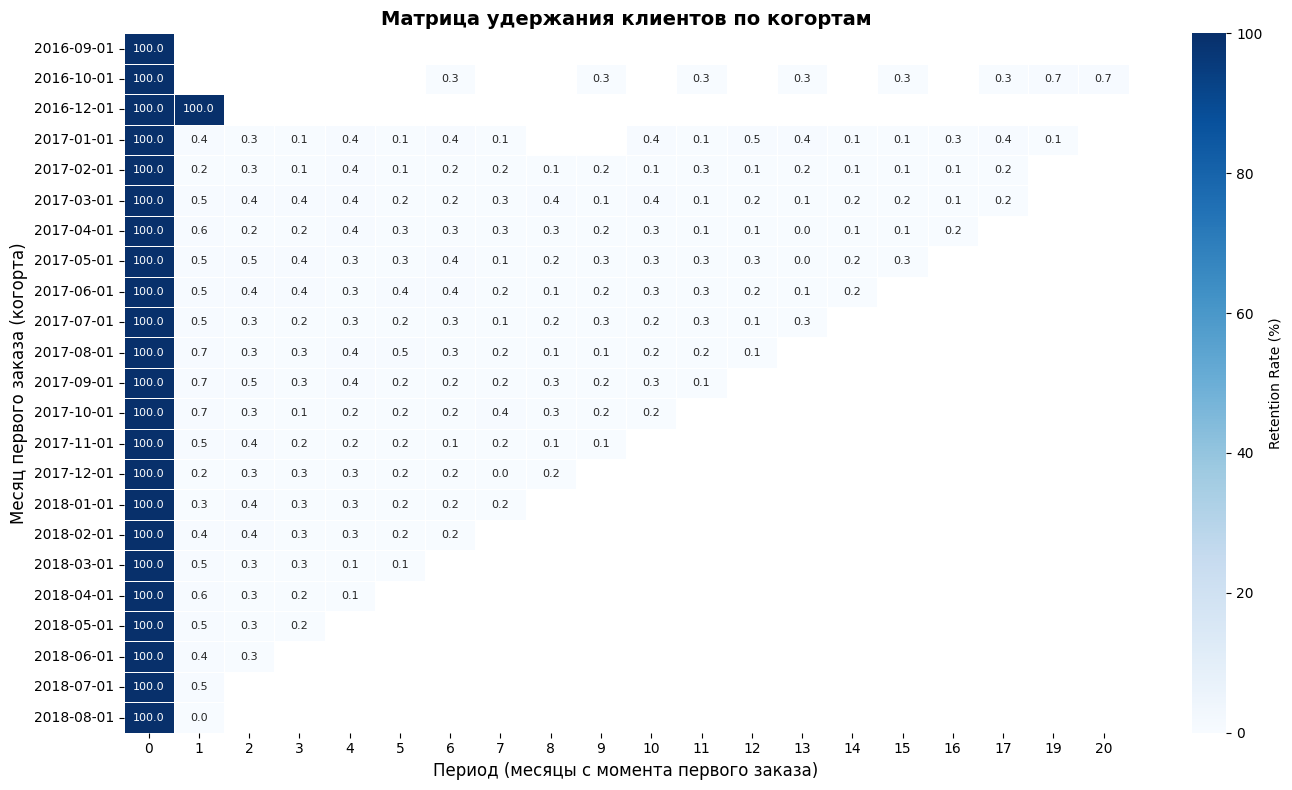

In [16]:
# КОГОРТНЫЙ АНАЛИЗ 

query_cohort = """
WITH cohort_calc AS (
    SELECT 
        customer_unique_id,
        order_id,
        order_purchase_timestamp,
        total_payment,
        DATE(MIN(order_purchase_timestamp) OVER (PARTITION BY customer_unique_id), 'start of month') AS cohort_month,
        DATE(order_purchase_timestamp, 'start of month') AS order_month,
        CAST((strftime('%Y', order_purchase_timestamp) - strftime('%Y', MIN(order_purchase_timestamp) OVER (PARTITION BY customer_unique_id))) * 12 +
             (strftime('%m', order_purchase_timestamp) - strftime('%m', MIN(order_purchase_timestamp) OVER (PARTITION BY customer_unique_id))) AS INTEGER) AS cohort_period
    FROM master_table
),
cohort_retention AS (
    SELECT 
        cohort_month,
        cohort_period,
        COUNT(DISTINCT customer_unique_id) AS customers
    FROM cohort_calc
    GROUP BY cohort_month, cohort_period
)
SELECT 
    cohort_month,
    cohort_period,
    customers,
    ROUND(customers * 100.0 / FIRST_VALUE(customers) OVER (PARTITION BY cohort_month ORDER BY cohort_period), 1) AS retention_rate_pct
FROM cohort_retention
ORDER BY cohort_month, cohort_period
"""

cohort_df = pd.read_sql_query(query_cohort, conn)

# Создаём матрицу удержания
cohort_pivot = cohort_df.pivot(index='cohort_month', columns='cohort_period', values='retention_rate_pct')


print("МАТРИЦА УДЕРЖАНИЯ (RETENTION RATE %)")

print(cohort_pivot.round(1))

# ВИЗУАЛИЗАЦИЯ КОГОРТНОЙ МАТРИЦЫ

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))
sns.heatmap(
    cohort_pivot, 
    annot=True,           # Показываем значения
    fmt='.1f',            # Формат чисел (1 десятичный знак)
    cmap='Blues',         # Цветовая схема
    cbar_kws={'label': 'Retention Rate (%)'},
    linewidths=0.5,       # Линии между ячейками
    linecolor='white',
    square=False,
    annot_kws={'size': 8}
)
plt.title('Матрица удержания клиентов по когортам', fontsize=14, fontweight='bold')
plt.xlabel('Период (месяцы с момента первого заказа)', fontsize=12)
plt.ylabel('Месяц первого заказа (когорта)', fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



RFM-СЕГМЕНТАЦИЯ

Распределение клиентов по сегментам:
customer_segment
Нужно стимулировать    22281
Обычные                22246
Уходящие               15398
VIP                    15226
Перспективные          11130
Лояльные                7827
Name: count, dtype: int64

Метрики по сегментам:
                     Клиенты  Средний чек  Общая выручка  Средняя частота  \
customer_segment                                                            
VIP                    15226       427.71     6512331.89             1.08   
Лояльные                7827       114.34      894910.40             1.03   
Нужно стимулировать    22281        55.77     1242609.19             1.00   
Обычные                22246       323.44     7195281.29             1.05   
Перспективные          11130       300.08     3339893.61             1.06   
Уходящие               15398        56.52      870306.62             1.00   

                     Средняя давность  
customer_segment                       
VIP      

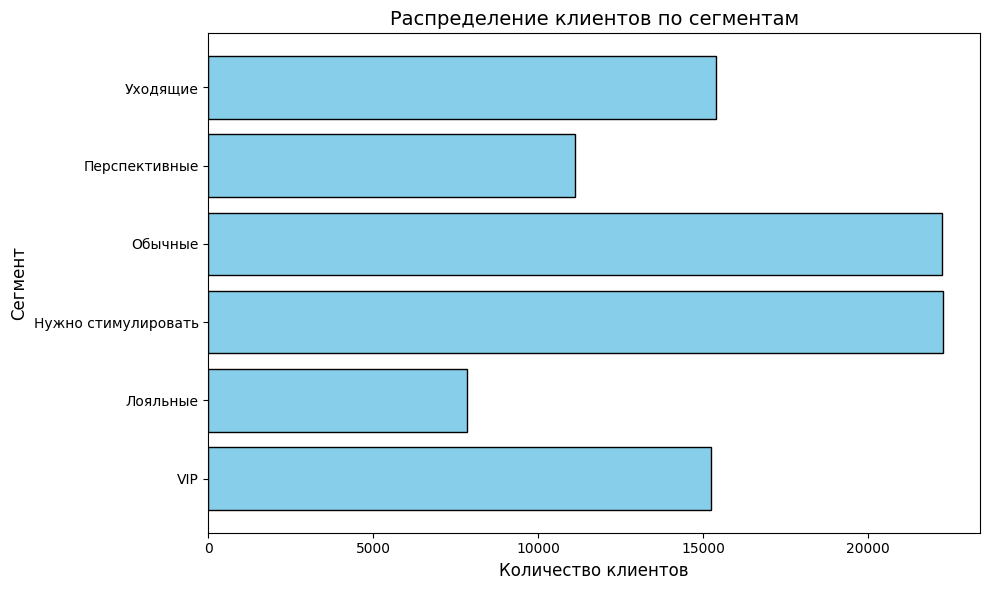

In [17]:
# RFM-СЕГМЕНТАЦИЯ 


query_rfm = """
WITH max_date AS (
    SELECT MAX(order_purchase_timestamp) AS last_date FROM master_table
),
rfm_calc AS (
    SELECT 
        customer_unique_id,
        MAX(order_purchase_timestamp) AS last_order,
        COUNT(DISTINCT order_id) AS frequency,
        SUM(total_payment) AS monetary,
        ROUND(julianday((SELECT last_date FROM max_date)) - julianday(MAX(order_purchase_timestamp)), 0) AS recency_days
    FROM master_table
    GROUP BY customer_unique_id
),
rfm_scores AS (
    SELECT 
        customer_unique_id,
        recency_days,
        frequency,
        monetary,
        NTILE(5) OVER (ORDER BY recency_days DESC) AS recency_score,
        NTILE(5) OVER (ORDER BY frequency ASC) AS frequency_score,
        NTILE(5) OVER (ORDER BY monetary ASC) AS monetary_score
    FROM rfm_calc
)
SELECT 
    customer_unique_id,
    recency_days,
    frequency,
    ROUND(monetary, 2) AS monetary,
    recency_score,
    frequency_score,
    monetary_score,
    recency_score || frequency_score || monetary_score AS rfm_score,
    CASE 
        WHEN recency_score >= 4 AND frequency_score >= 4 AND monetary_score >= 4 THEN 'VIP'
        WHEN recency_score >= 4 AND frequency_score >= 3 THEN 'Лояльные'
        WHEN recency_score >= 3 AND frequency_score >= 3 AND monetary_score >= 3 THEN 'Перспективные'
        WHEN recency_score >= 3 AND frequency_score >= 1 THEN 'Нужно стимулировать'
        WHEN recency_score <= 2 AND frequency_score <= 2 THEN 'Уходящие'
        ELSE 'Обычные'
    END AS customer_segment
FROM rfm_scores
ORDER BY recency_score DESC, frequency_score DESC, monetary_score DESC
"""

rfm_df = pd.read_sql_query(query_rfm, conn)


print("RFM-СЕГМЕНТАЦИЯ")


# Распределение по сегментам
segment_dist = rfm_df['customer_segment'].value_counts()
print("\nРаспределение клиентов по сегментам:")
print(segment_dist)

# Метрики по сегментам
segment_metrics = rfm_df.groupby('customer_segment').agg({
    'customer_unique_id': 'count',
    'monetary': ['mean', 'sum'],
    'frequency': 'mean',
    'recency_days': 'mean'
}).round(2)
segment_metrics.columns = ['Клиенты', 'Средний чек', 'Общая выручка', 'Средняя частота', 'Средняя давность']
print("\nМетрики по сегментам:")
print(segment_metrics)

# Горизонтальная диаграмма для количества клиентов
plt.figure(figsize=(10, 6))
plt.barh(segment_metrics.index, segment_metrics['Клиенты'], 
         color='skyblue', edgecolor='black')
plt.title('Распределение клиентов по сегментам', fontsize=14)
plt.xlabel('Количество клиентов', fontsize=12)
plt.ylabel('Сегмент', fontsize=12)
plt.tight_layout()
plt.show()

## ПРИОРИТЕТНЫЕ ЗАДАЧИ ДЛЯ ПРОДУКТОВОЙ КОМАНДЫ

# Критично: Снизить процент задержек до < 3% → повысить среднюю оценку до 4.0+
# Высокий приоритет: Активно развивать регионы за пределами SP (реклама, логистика)
# Средний приоритет: Запустить категорийные акции в health_beauty и watches_gifts
# Стратегически: Использовать данные по часам для персонализации коммуникаций
